In [69]:
require(data.table)
require(tidyverse)
require(phyloseq)
require(ggplot2)
require(RColorBrewer)
require(metacoder)
require(vegan)

# Are there differences in microbe population between coral species in the same region?
- what about in the same transect, where the environment is more similar?

## phyloseq cleanup

In [109]:
ps<-readRDS(file = "/work/pi_sarah_gignouxwolfsohn_uml_edu/caroline/BEL_16S_ITS2/BEL_16S_outputs/ps_16S.rds")
#removing any taxa that don't show up in any samples to speed up the process
ps <- prune_taxa(taxa_sums(ps) > 0, ps)
ps

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 193447 taxa and 470 samples ]
sample_data() Sample Data:       [ 470 samples by 9 sample variables ]
tax_table()   Taxonomy Table:    [ 193447 taxa by 6 taxonomic ranks ]

In [110]:
#normalizing ps by converting rawcounts into relative abundances
#so samples with more reads wont be over represented
#using ps bc only to the count data (OTU table), while preserving the rest of the object
ps_norm = transform_sample_counts(ps, function(x) 1E6 * x / sum(x))

In [111]:
#isolate just bacteria
ps_norm_bac=subset_taxa(ps_norm, Kingdom=="Bacteria")
#remove chloroplast order
ps_norm_nochlo=subset_taxa(ps_norm_bac, Order!="Chloroplast")
#remove mitochondria family
ps_norm_nomit=subset_taxa(ps_norm_nochlo, Family!="Mitochondria")
ps_norm_nomit

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 64055 taxa and 470 samples ]
sample_data() Sample Data:       [ 470 samples by 9 sample variables ]
tax_table()   Taxonomy Table:    [ 64055 taxa by 6 taxonomic ranks ]

In [112]:
unique(sample_data(ps_norm_nomit)$Month_year)

[1] Jan 2024 Feb 2024 Apr 2024 May 2022 Jun 2019 Jun 2024 Aug 2024 Sep 2023
 [9] Oct 2019 Nov 2023 Dec 2022 Dec 2023
12 Levels: May 2022 Sep 2023 Feb 2024 Aug 2024 Dec 2023 Nov 2023 ... Jan 2024

# How are host coral species changing over time?
## ps object for family taxa

### make sure dates are in chronological order

In [113]:
# 2. reorder MonthYear as a factor in chronological order
sample_data(ps_norm_nomit)$Month_year <- factor(sample_data(ps_norm_nomit)$Month_year,levels = c("Jun 2019","May 2022","Oct 2022", "Dec 2022", "Sep 2023","Nov 2023","Dec 2023","Jan 2024","Feb 2024","Apr 2024","Jun 2024","Aug 2024"))



In [115]:
    # how many unique family taxa are there?
length(unique(tax_table(ps_norm_nomit)[, "Family"]))

[1] 526

In [117]:
ps_fam=tax_glom(ps_norm_nomit, taxrank= "Family")

#need to isolate top 50 bc I made ps_past based on norm_nomit instead of ps_fam
top50_fam <- names(sort(taxa_sums(ps_fam), decreasing=TRUE))[1:50] 
top50_fam <- prune_taxa(top50_fam, ps_fam) 
#confirm that it has been reduced
length(unique(tax_table(top50_fam)[, "Family"]))

[1] 50

In [118]:
unique(sample_data(ps_fam)$Month_year)

[1] Jan 2024 Feb 2024 Apr 2024 May 2022 Jun 2019 Jun 2024 Aug 2024 Sep 2023
 [9] <NA>     Nov 2023 Dec 2022 Dec 2023
12 Levels: Jun 2019 May 2022 Oct 2022 Dec 2022 Sep 2023 Nov 2023 ... Aug 2024

### family plot

In [105]:
### plot sizing
options(repr.plot.width=40, repr.plot.height=30)

Warning message in geom_text(aes(label = Family, fill = Family), position = position_stack(vjust = 0.5), :
“Ignoring unknown aesthetics: fill”


<Guides[1] ggproto object>

colour : <GuideLegend>

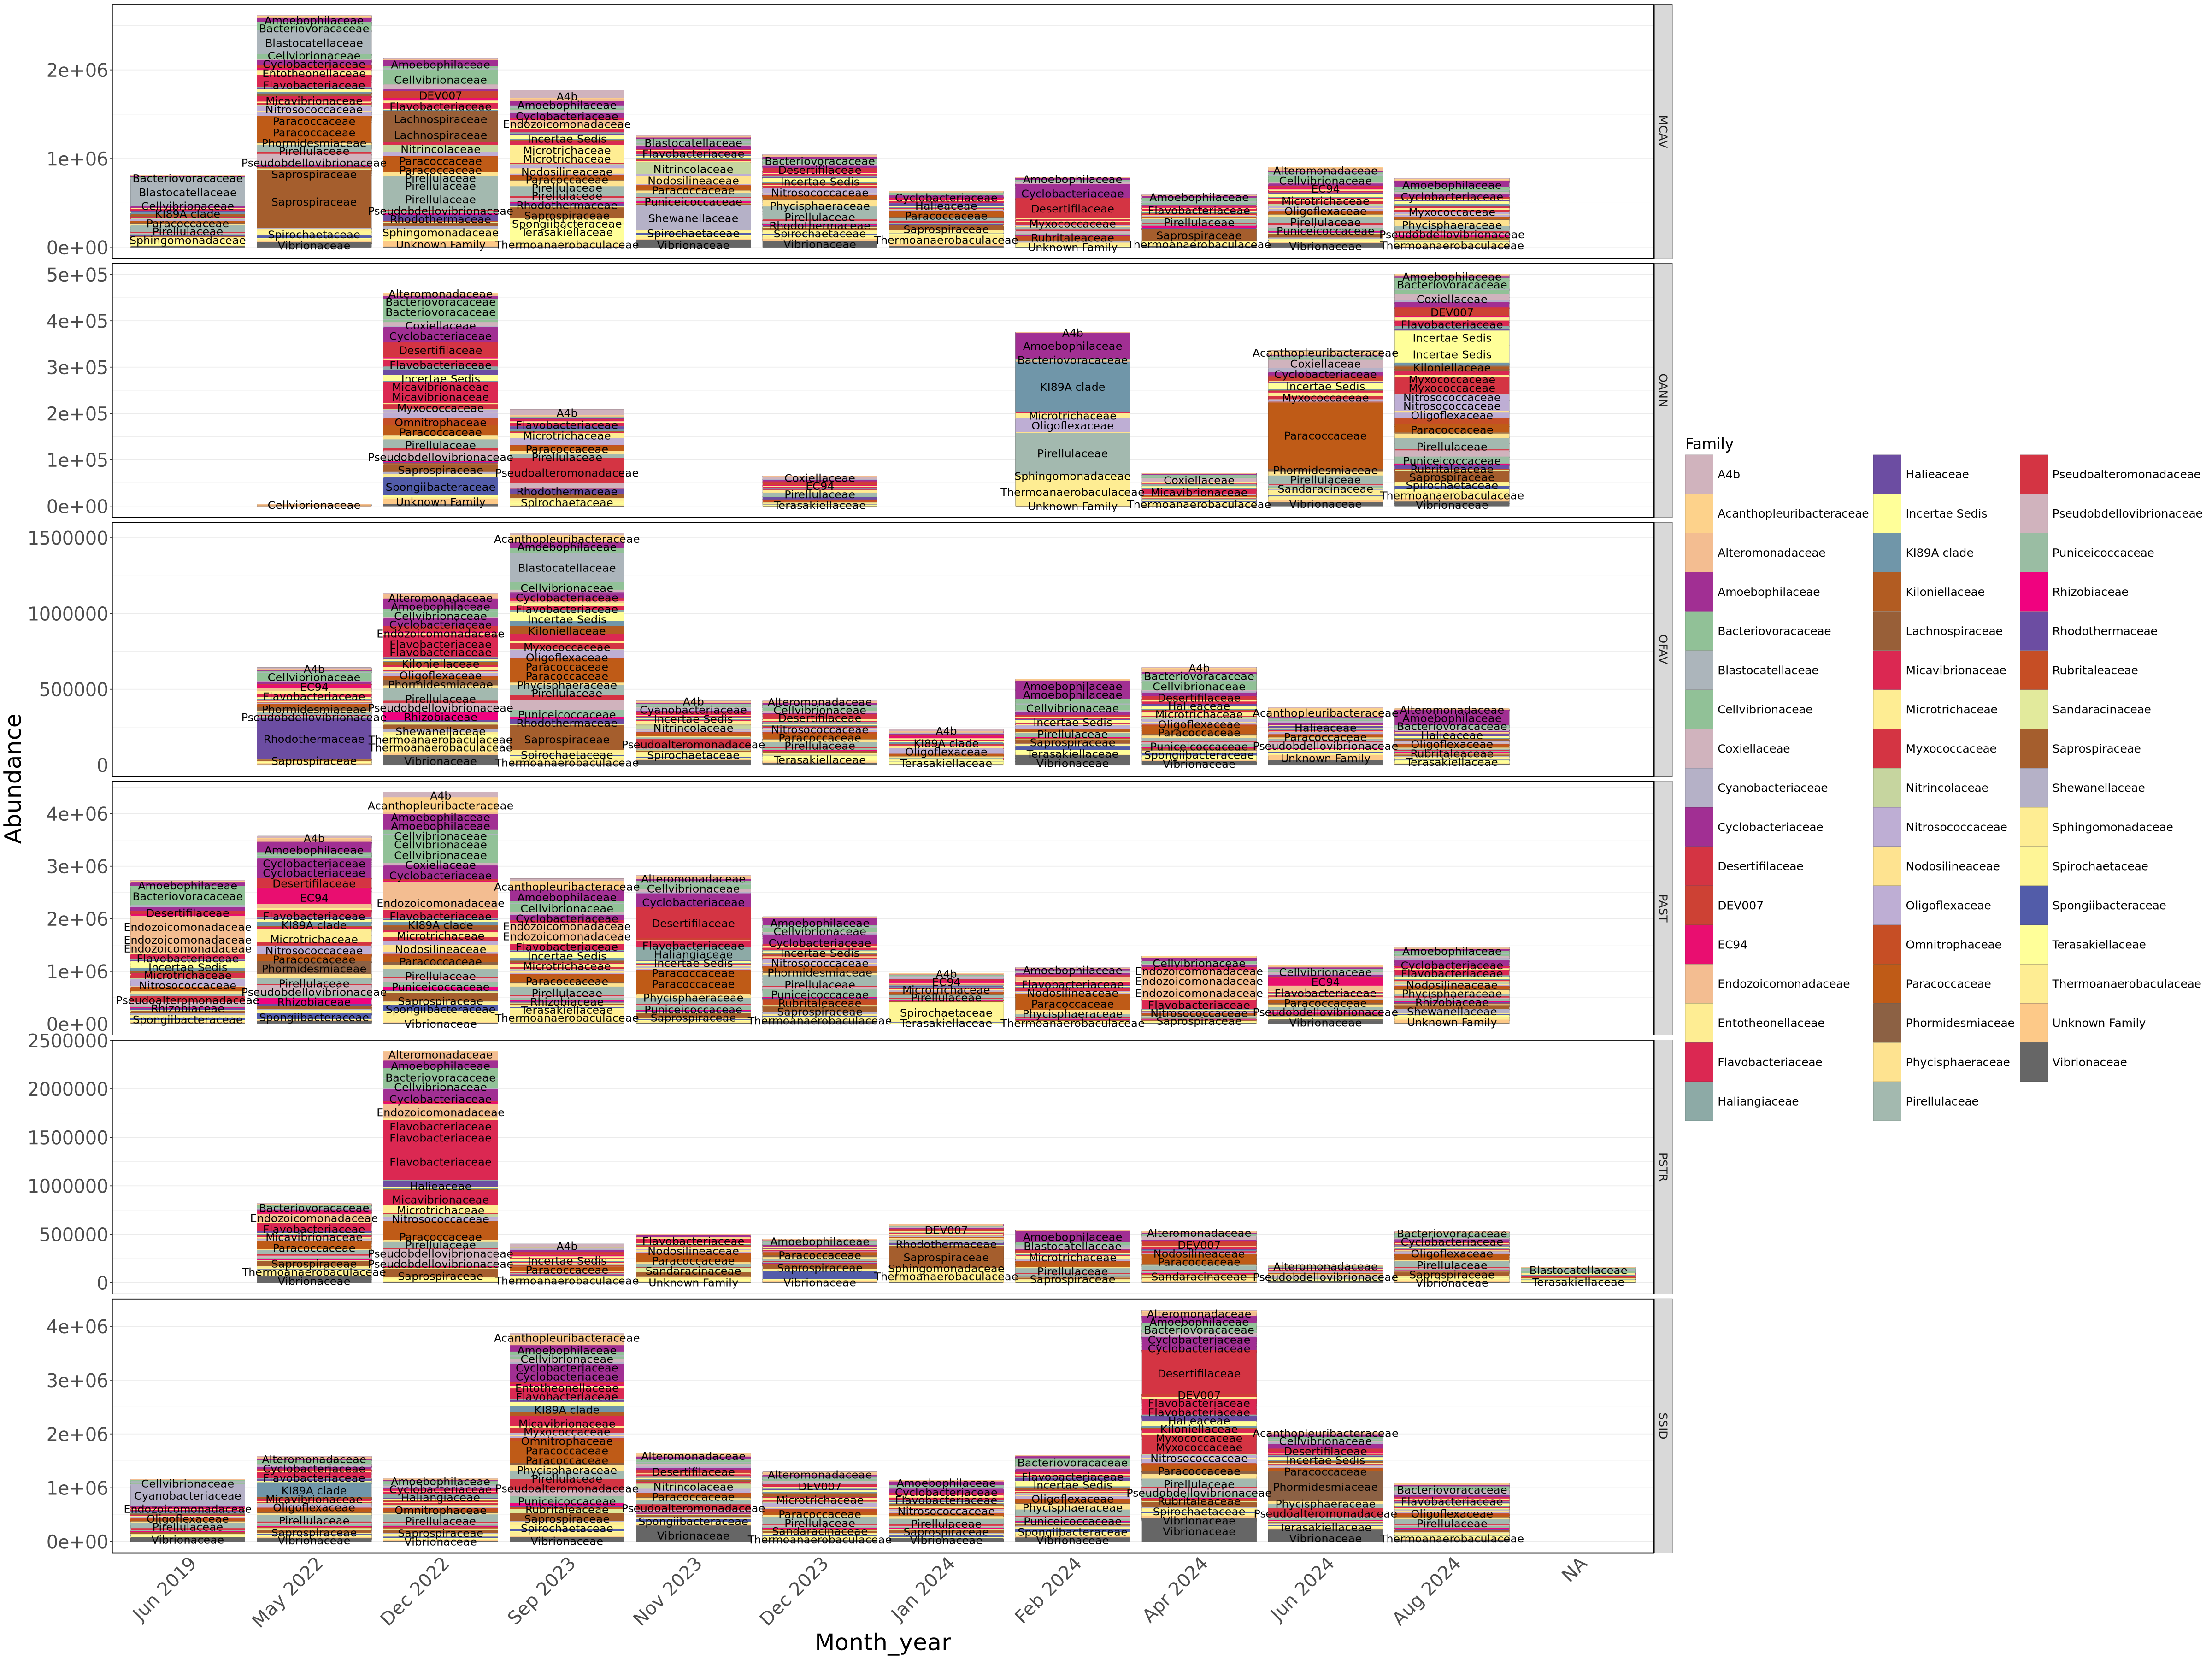

In [106]:
fam <- plot_bar(ps_fam, x="Month_year", fill = "Family") +
  facet_wrap(Species ~., strip.position = "right",  ncol = 1, scales = "free_y") + # Set desired font size
  geom_bar(aes(color = Family, fill = Family), 
           stat = "identity", position = "stack") +
  geom_text(aes(label = Family, fill = Family),
            position = position_stack(vjust = 0.5),
            color = "black", size = 5, check_overlap = TRUE) +
  scale_fill_manual(values = famcolors, drop = TRUE) +
  scale_color_manual(values = famcolors, drop = TRUE) +
  theme_bw() +
  theme(strip.text = element_text(size = 15), #facet text size
    legend.position = "right",
      legend.title = element_text(size = 20),
  legend.text = element_text(size = 15),
  legend.key.width = unit(1.3, "cm"),     # make the legend keys wider
  legend.key.height = unit(1.8, "cm"),   # make them taller
    panel.border = element_rect(color = "black", fill = NA, linewidth = 1),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1),
    text = element_text(size = 30)
  )
guides(color = guide_legend(override.aes = list(size = 6))) 
fam

In [ ]:
ggsave("/work/pi_sarah_gignouxwolfsohn_uml_edu/caroline/BEL_16S_ITS2/BEL_16S_outputs/apr_lab_meeting/species_family.png", plot = fam, width = 40, height = 30, units = "in", dpi = 300)

## ps objects for each host species

In [107]:
#new dataframes for each species 
ps_mcav <- subset_samples(ps_norm_nomit, Species == "MCAV")
ps_pstr <- subset_samples(ps_norm_nomit, Species == "PSTR")
ps_ofav <- subset_samples(ps_norm_nomit, Species == "OFAV")
ps_ssid <- subset_samples(ps_norm_nomit, Species == "SSID")
ps_oann <- subset_samples(ps_norm_nomit, Species == "OANN")
ps_past <- subset_samples(ps_norm_nomit, Species == "PAST") 

In [108]:
print(sample_data(ps_pstr))

                              Health_status colony   Date_16S Condition Species
012024_BEL_CBC_T1_563_PSTR          Healthy   1_12   3_6_2025   Healthy    PSTR
012024_BEL_CBC_T3_642_PSTR          Healthy   3_20  2_10_2026   Healthy    PSTR
012024_BEL_CBC_T3_644_PSTR  Bleached_Tissue   3_70   2_9_2026       CLP    PSTR
012024_BEL_CBC_T4_661_PSTR  Bleached_Tissue   4_98   3_6_2025       CLB    PSTR
012024_BEL_CBC_T4_663_PSTR          Healthy   4_79  3_10_2025   Healthy    PSTR
022024_BEL_CBC_T1_776_PSTR          Healthy   1_12   3_4_2025   Healthy    PSTR
022024_BEL_CBC_T3_849_PSTR          Healthy   3_20   3_9_2026   Healthy    PSTR
022024_BEL_CBC_T3_851_PSTR          Healthy   3_70  1_23_2025   Healthy    PSTR
022024_BEL_CBC_T4_871_PSTR  Bleached_Tissue   4_98  3_11_2026       CLP    PSTR
022024_BEL_CBC_T4_872_PSTR          Healthy   4_79  2_11_2026   Healthy    PSTR
042024_BEL_CBC_T1_927_PSTR          Healthy   1_12   3_6_2025   Healthy    PSTR
042024_BEL_CBC_T3_949_PSTR          Heal

### plots

#### assigning colors for family taxa

In [77]:
#assigning colors
famcolors= colorRampPalette(brewer.pal(8, "Accent"))(50)

#Generate a random set of colors based on a df fam_taxa that assigns a random color to each spot in the list
fam_taxa <- unique(tax_table(ps_fam)[, "Family"])
    famcolors <- sample(famcolors, 50, length(fam_taxa))
    # naming my color palette so the random order stays the same
    famcolors<- setNames(famcolors, fam_taxa)

In [78]:
### plot sizing
options(repr.plot.width=30, repr.plot.height=15)

#### Porites asteroides

In [81]:
# how many unique family taxa are there?
length(unique(tax_table(ps_past)[, "Family"]))

[1] 526

Warning message in geom_text(aes(label = Family, fill = Family), position = position_stack(vjust = 0.5), :
“Ignoring unknown aesthetics: fill”


<Guides[1] ggproto object>

colour : <GuideLegend>

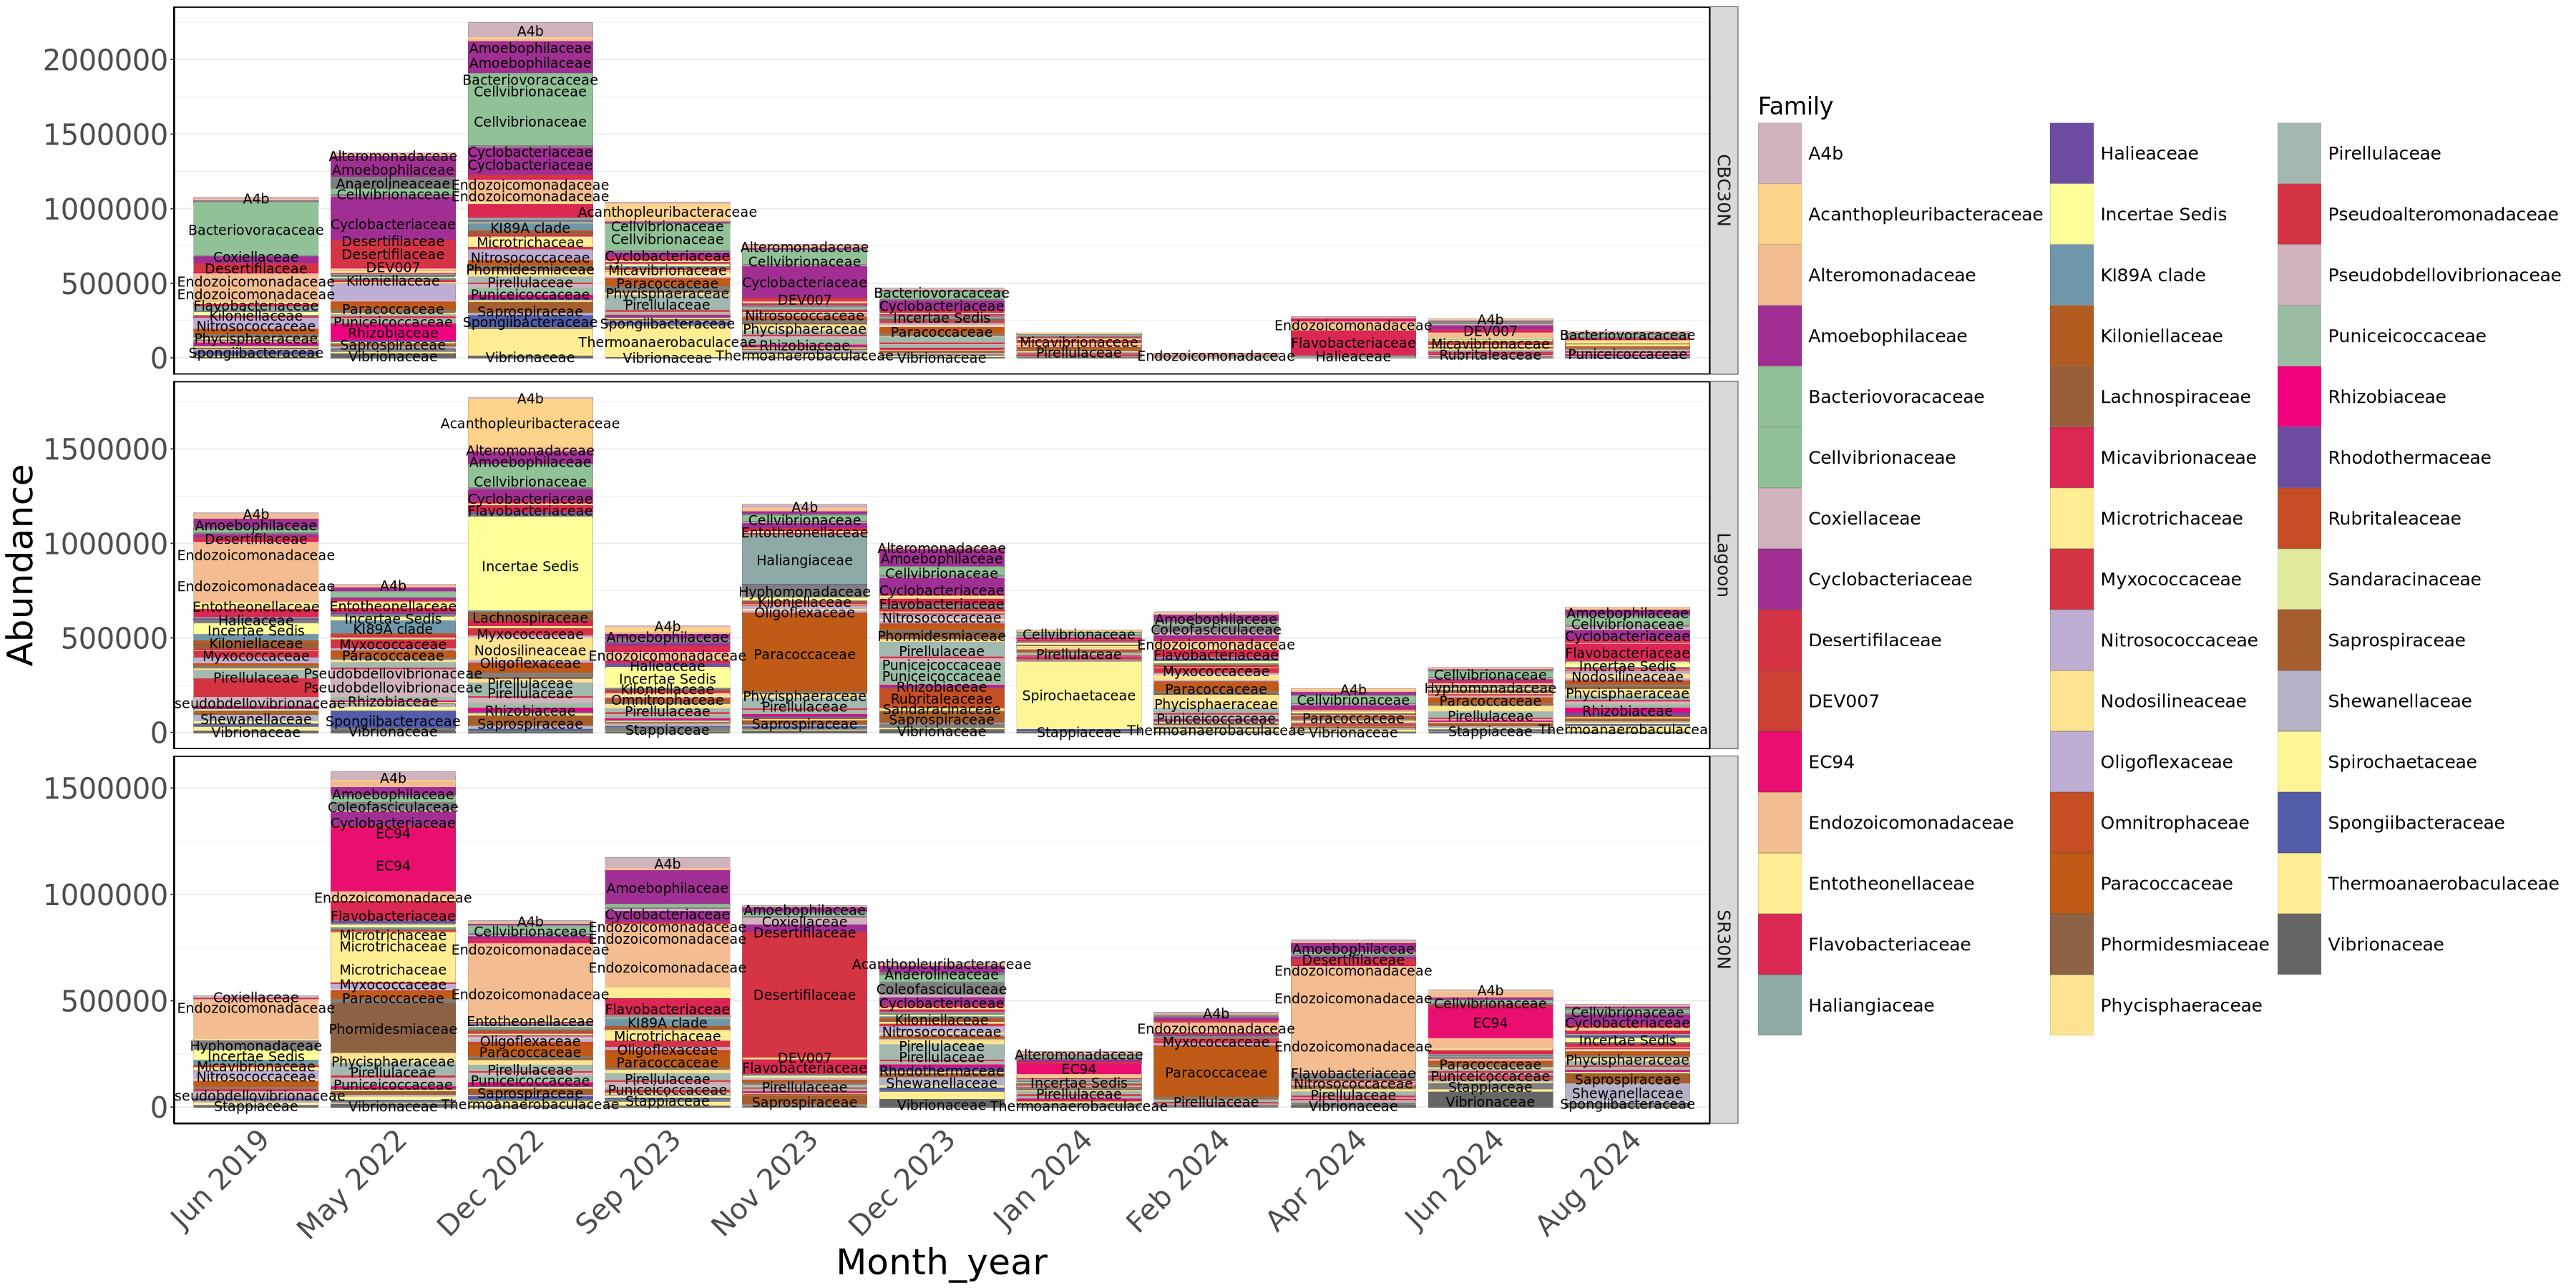

In [82]:
ps_past=tax_glom(ps_past, taxrank= "Family")

#need to isolate top 50 bc I made ps_past based on norm_nomit instead of ps_fam
top50_past <- names(sort(taxa_sums(ps_past), decreasing=TRUE))[1:50] 
top50_past <- prune_taxa(top50_past, ps_past) 

#plot
past <- plot_bar(top50_past, x="Month_year", fill = "Family") +
  facet_wrap(Transect ~., strip.position = "right",  ncol = 1, scales = "free_y") + # Set desired font size
  geom_bar(aes(color = Family, fill = Family), 
           stat = "identity", position = "stack") +
  geom_text(aes(label = Family, fill = Family),
            position = position_stack(vjust = 0.5),
            color = "black", size = 4, check_overlap = TRUE) +
  scale_fill_manual(values = famcolors, drop = TRUE) +
  scale_color_manual(values = famcolors, drop = TRUE) +
  theme_bw() +
  theme(strip.text = element_text(size = 15), #facet text size
    legend.position = "right",
      legend.title = element_text(size = 20),
  legend.text = element_text(size = 15),
  legend.key.width = unit(1.3, "cm"),     # make the legend keys wider
  legend.key.height = unit(1.8, "cm"),   # make them taller
    panel.border = element_rect(color = "black", fill = NA, linewidth = 1),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1),
    text = element_text(size = 30)
  )
guides(color = guide_legend(override.aes = list(size = 6))) 
past

### Pseudodiploria strigosa

Warning message in geom_text(aes(label = Family, fill = Family), position = position_stack(vjust = 0.5), :
“Ignoring unknown aesthetics: fill”


<Guides[1] ggproto object>

colour : <GuideLegend>

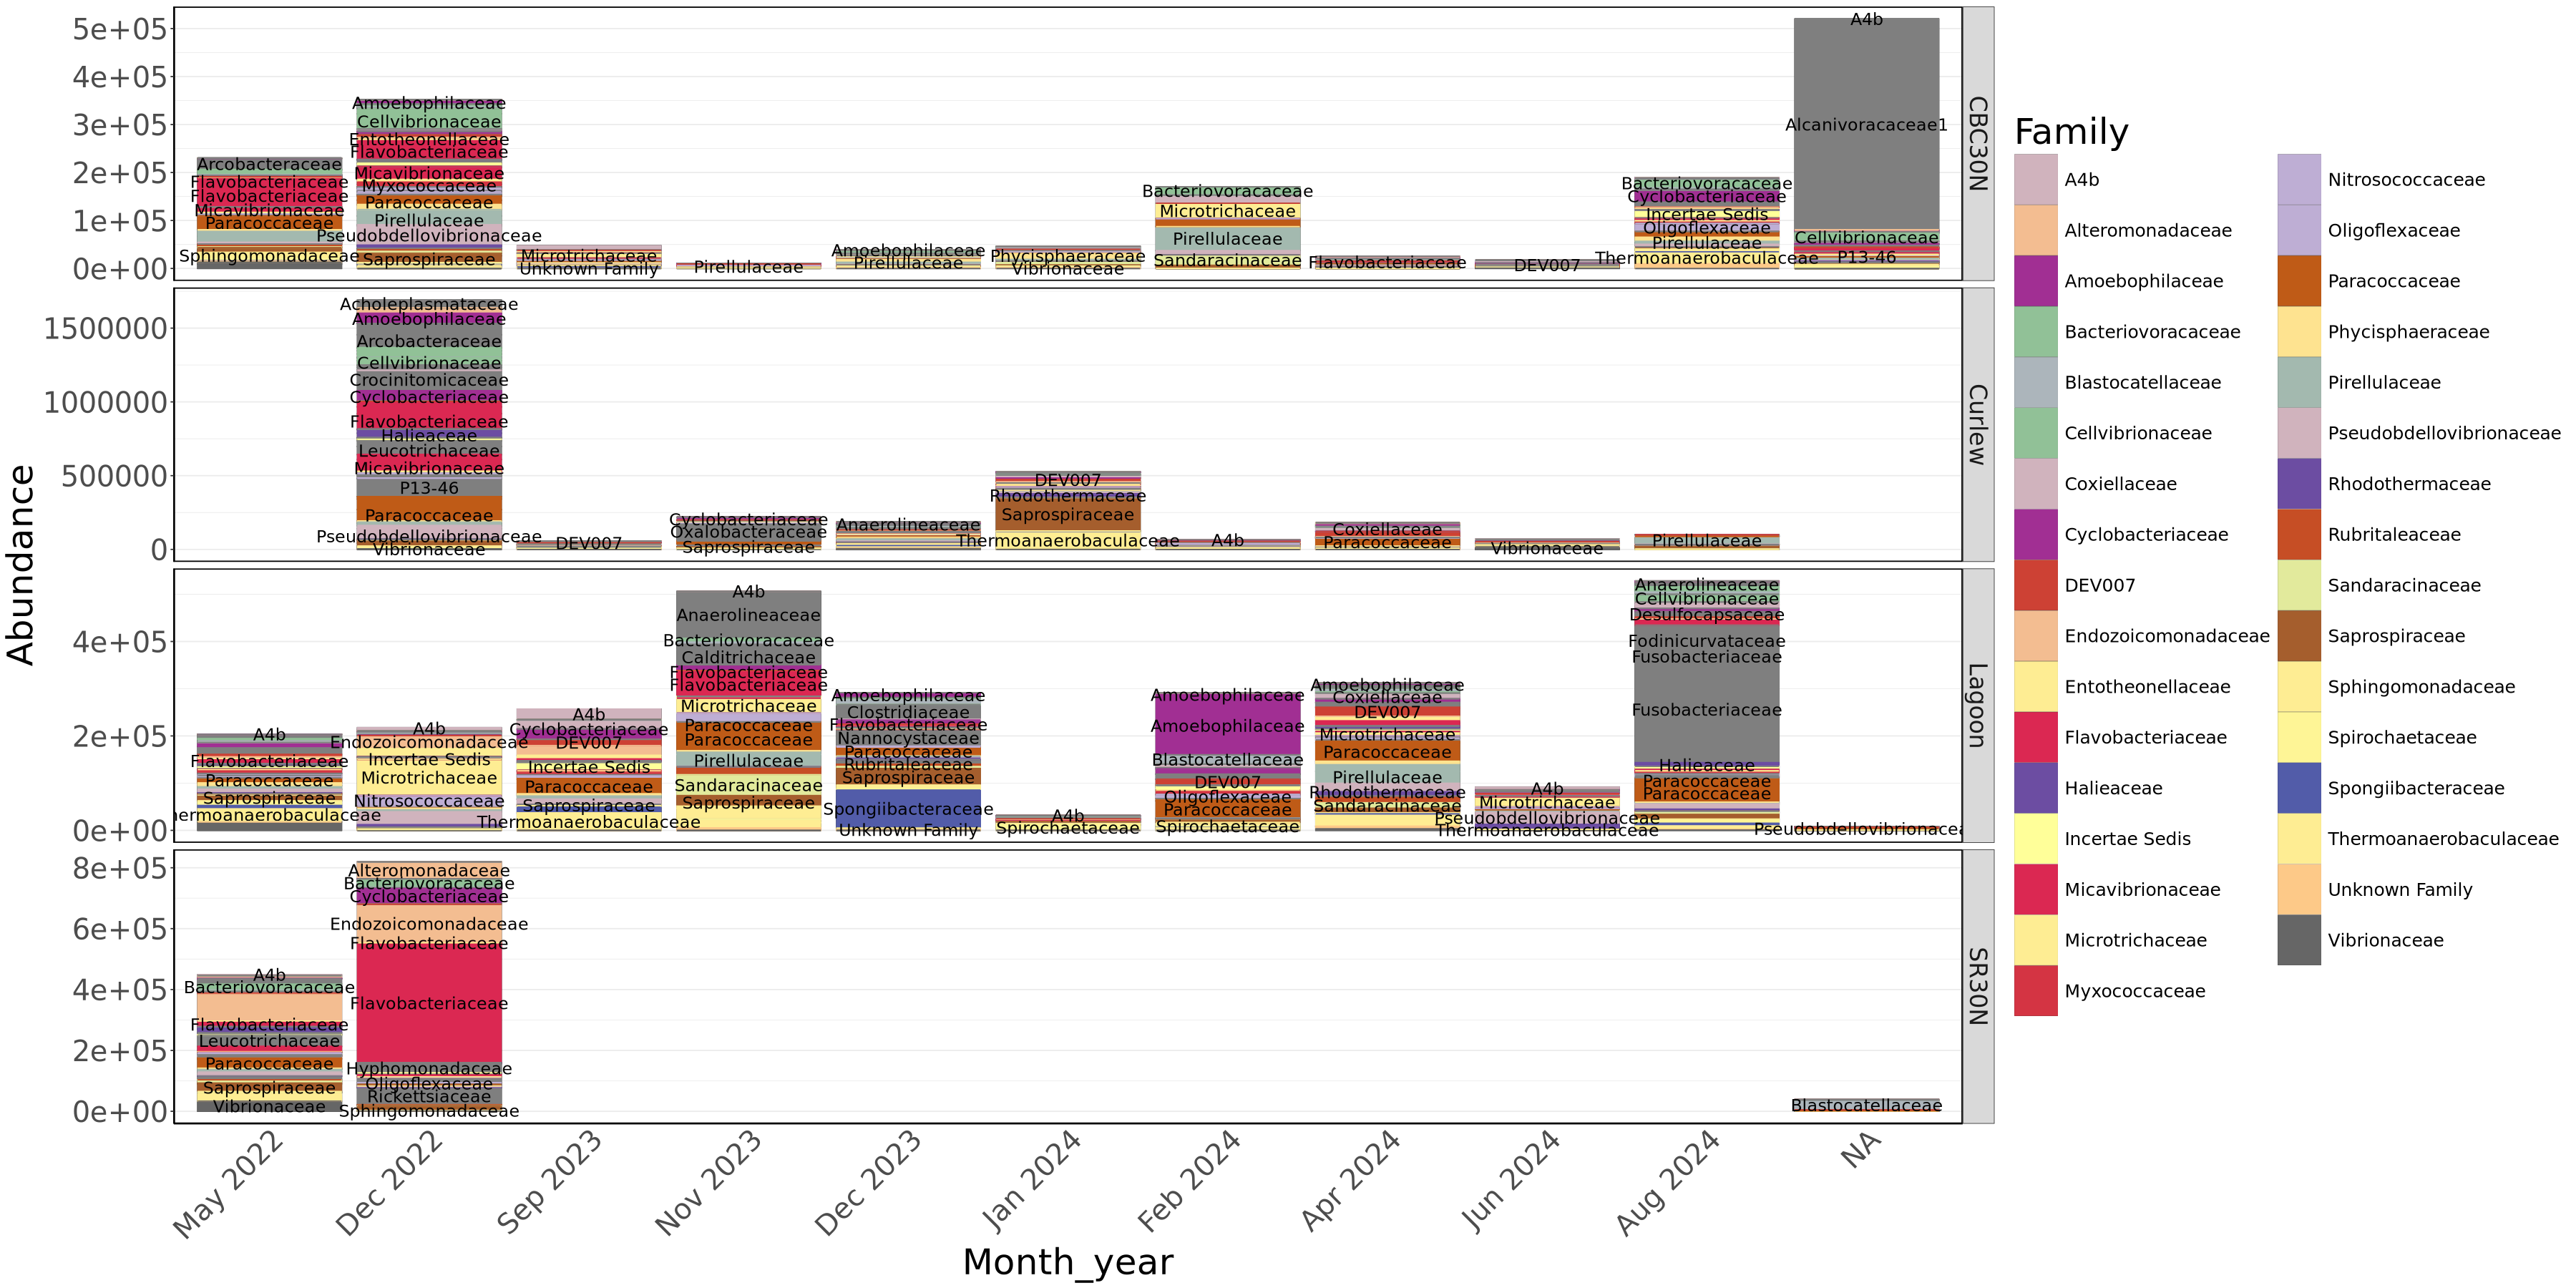

In [83]:
#plot
fam_pstr=tax_glom(ps_pstr, taxrank= "Family")

top50_pstr <- names(sort(taxa_sums(fam_pstr), decreasing=TRUE))[1:50] 
fam_pstr <- prune_taxa(top50_pstr, fam_pstr) 
fam_pstr <- plot_bar(fam_pstr, x="Month_year", fill="Family") +
   facet_wrap(Transect ~., strip.position = "right", ncol = 1, scales = "free_y") +
  geom_bar(aes(color = Family, fill = Family), 
           stat = "identity", position = "stack") +
  geom_text(aes(label = Family, fill = Family),
            position = position_stack(vjust = 0.5),
            color = "black", size = 5, check_overlap = TRUE) +
  scale_fill_manual(values = famcolors, drop = TRUE) +
  scale_color_manual(values = famcolors, drop = TRUE) +
  theme_bw() +
  theme(strip.text = element_text(size = 20), #facet text size
    legend.position = "right",
      legend.title = element_text(size = 30),
  legend.text = element_text(size = 15),
  legend.key.width = unit(1.3, "cm"),     # make the legend keys wider
  legend.key.height = unit(1.5, "cm"),   # make them taller
    panel.border = element_rect(color = "black", fill = NA, linewidth = 1),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1),
    text = element_text(size = 30)
  )
guides(color = guide_legend(override.aes = list(size = 6))) 
fam_pstr

### Siderastrea sidera

Warning message in geom_text(aes(label = Family, fill = Family), position = position_stack(vjust = 0.5), :
“Ignoring unknown aesthetics: fill”


<Guides[1] ggproto object>

colour : <GuideLegend>

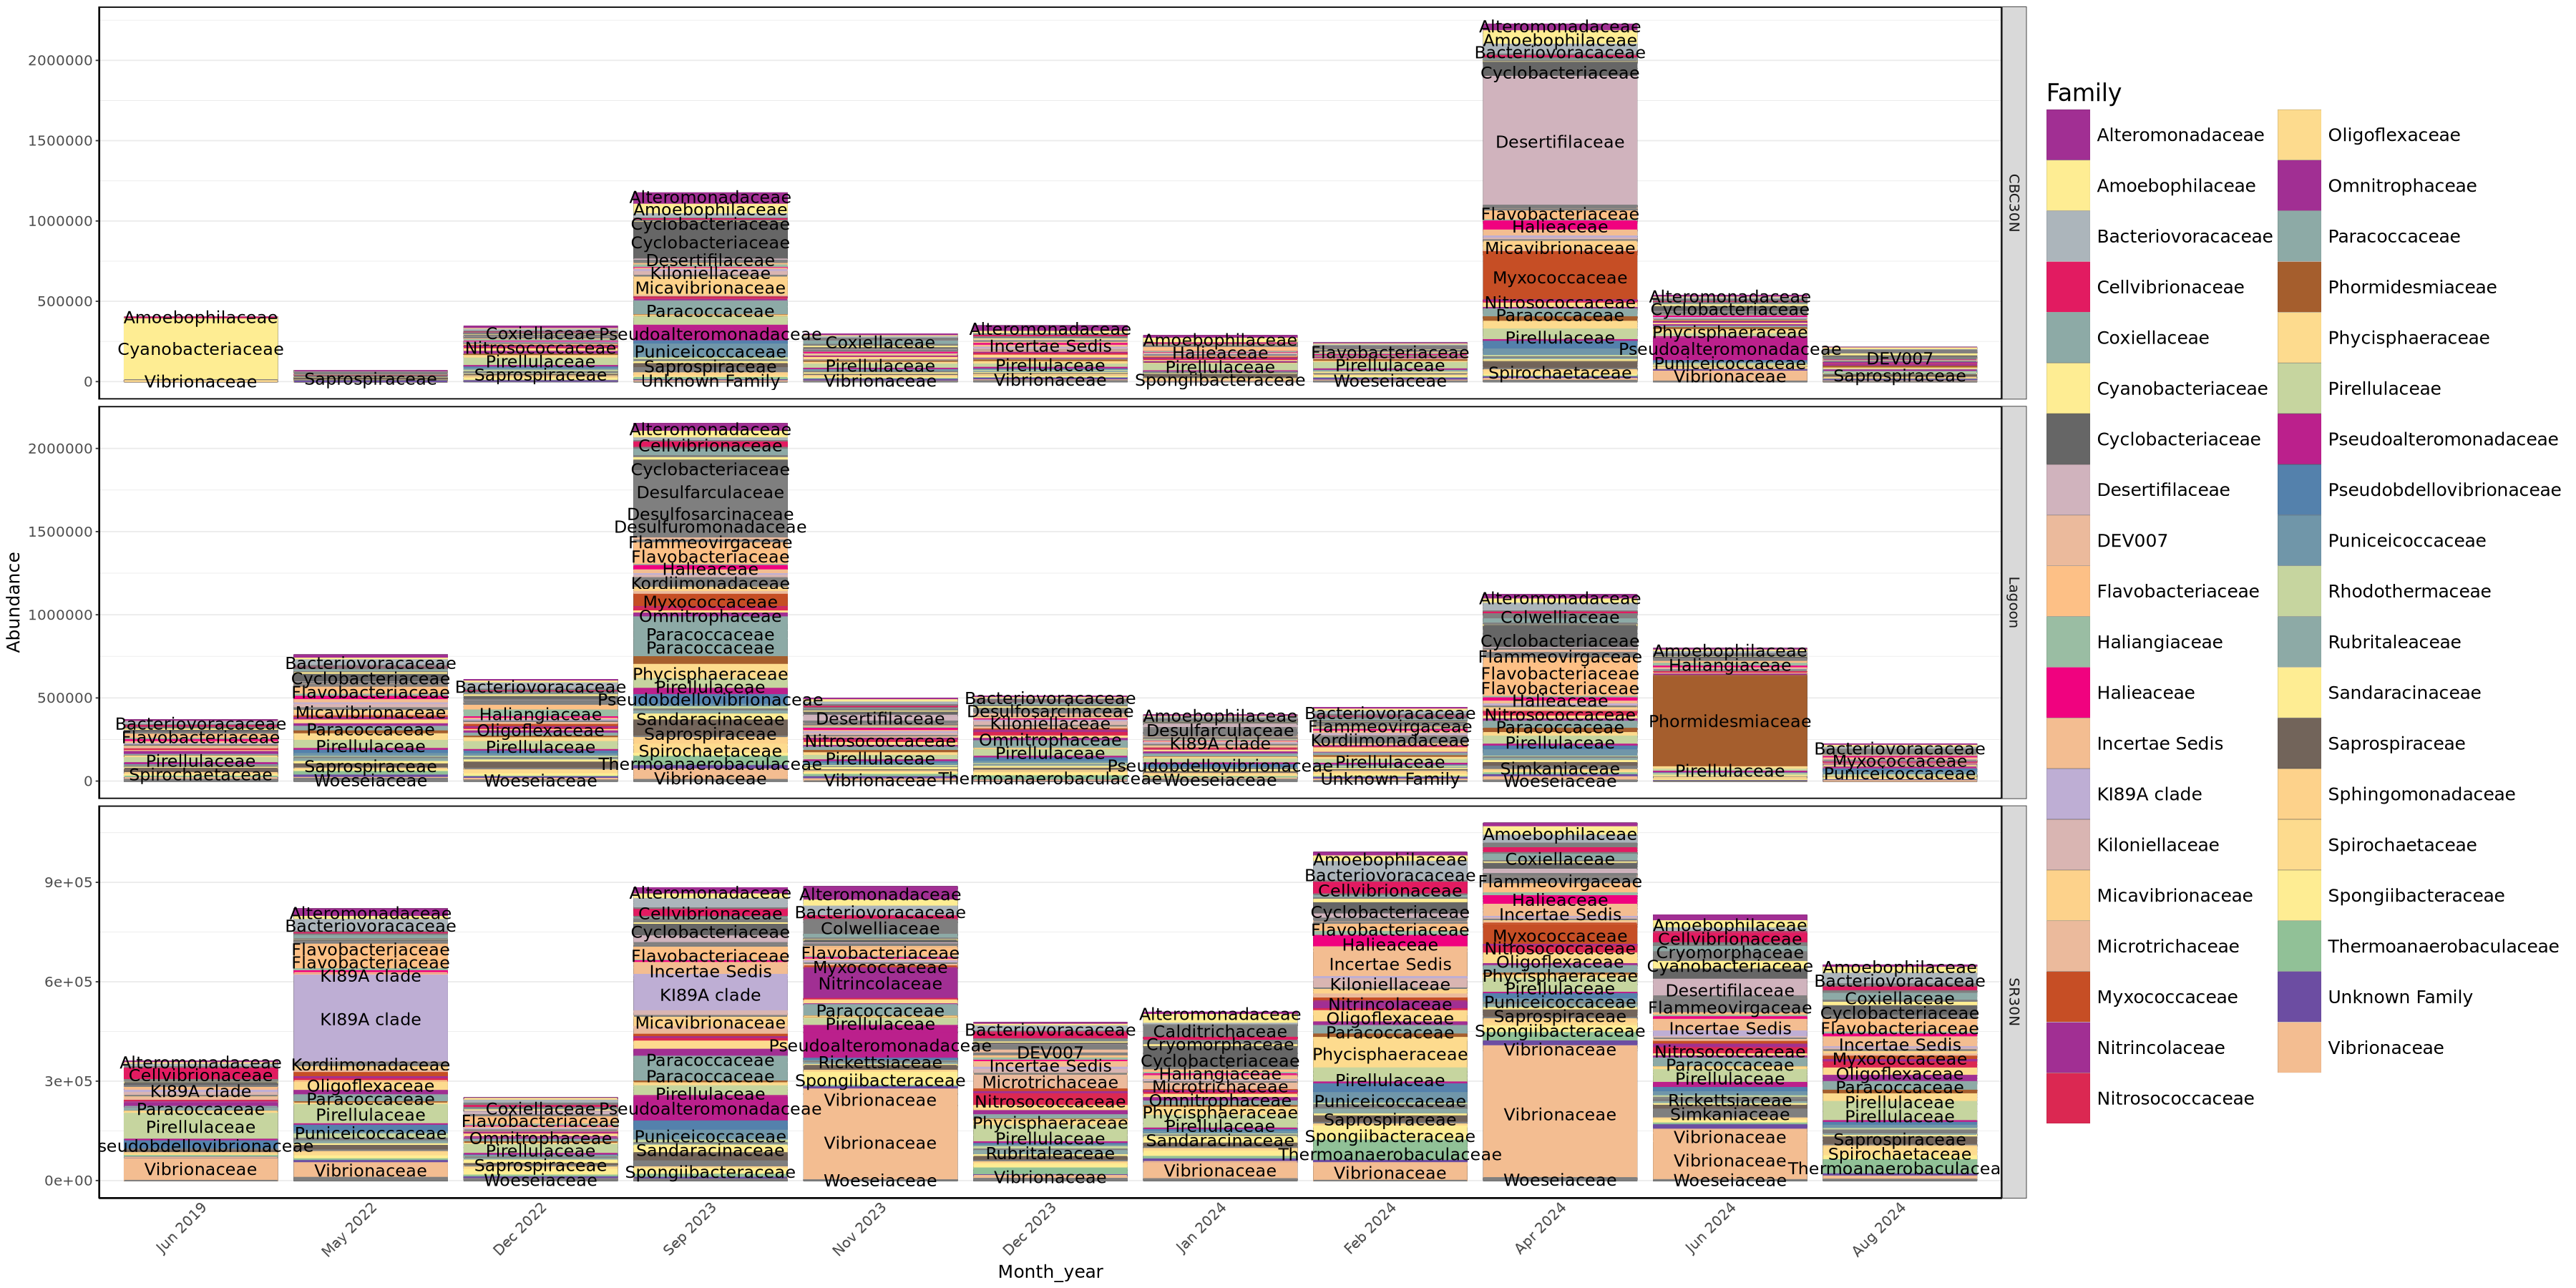

In [46]:
#plot
fam_ssid=tax_glom(ps_ssid, taxrank= "Family")

top50_ssid <- names(sort(taxa_sums(fam_ssid), decreasing=TRUE))[1:50] 
fam_ssid  <- prune_taxa(top50_ssid, fam_ssid) 
fam_ssid  <- plot_bar(fam_ssid , x="Month_year", fill="Family") +
   facet_wrap(Transect ~., strip.position = "right", ncol = 1, scales = "free_y") +
  geom_bar(aes(color = Family, fill = Family), 
           stat = "identity", position = "stack") +
  geom_text(aes(label = Family, fill = Family),
            position = position_stack(vjust = 0.5),
            color = "black", size = 5, check_overlap = TRUE) +
  scale_fill_manual(values = famcolors, drop = TRUE) +
  scale_color_manual(values = famcolors, drop = TRUE) +
  theme_bw() +

  theme(strip.text = element_text(size = 20), #facet text size
    legend.position = "right",
      legend.title = element_text(size = 30),
  legend.text = element_text(size = 20),
  legend.key.width = unit(1.3, "cm"),     # make the legend keys wider
  legend.key.height = unit(1.5, "cm"),   # make them taller
    panel.border = element_rect(color = "black", fill = NA, linewidth = 1),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1),
    text = element_text(size = 30)
  )
guides(color = guide_legend(override.aes = list(size = 6))) 
fam_ssid

In [47]:
## why am I seeing N/A values for Month_year?
unique(sample_data(ps_fam)$Month_year)
unique(sample_data(ps_pstr)$Month_year)

[1] Jan 2024 Feb 2024 Apr 2024 <NA>     May 2022 Jun 2019 Jun 2024 Aug 2024
 [9] Sep 2023 Nov 2023 Dec 2022 Dec 2023
12 Levels: Jun 2019 May 2022 Oct 2022 Dec 2022 Sep 2023 Nov 2023 ... Aug 2024

[1] Jan 2024 Feb 2024 Apr 2024 <NA>     May 2022 Jun 2019 Jun 2024 Aug 2024
 [9] Sep 2023 Oct 2019 Nov 2023 Dec 2022 Dec 2023
12 Levels: May 2022 Sep 2023 Feb 2024 Aug 2024 Dec 2023 Nov 2023 ... Jan 2024

[1] Jan 2024 Feb 2024 Apr 2024 May 2022 Jun 2024 Aug 2024 Sep 2023 <NA>    
 [9] Nov 2023 Dec 2022 Dec 2023
10 Levels: May 2022 Dec 2022 Sep 2023 Nov 2023 Dec 2023 Jan 2024 ... Aug 2024